# Import

In [1]:
# Importing modules
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

os.makedirs("outputs", exist_ok=True)

In [2]:
os.listdir(r'C:\Users\44794\Downloads\credit_risk_project')

['credit_risk_dataset.csv',
 'credit_risk_dataset_2.csv',
 'python_credit_risk_project',
 'sql_project']

In [3]:
# Importing data set
df = pd.read_csv(r'C:\Users\44794\Downloads\credit_risk_project\credit_risk_dataset_2.csv')

#Inspecting data structure
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
cols = ['person_income', 'person_age', 'loan_amnt']

for col in cols:
    avg = df[col].mean()
    print(avg)

66074.84846996715
27.73459992019889
9589.371105859243


In [5]:
# Converting the data set to SQL table
conn = sqlite3.connect("credit_risk.db")

df.to_sql("credit_risk", conn, index=False, if_exists="replace")

32581

In [6]:
query = "SELECT * FROM credit_risk LIMIT 5;"
df_test = pd.read_sql(query, conn)

print(df_test.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


# Data Understanding

In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
df.shape

(32581, 12)

In [9]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [10]:
# Data types
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

In [11]:
# Finding missing data
df1 = df.isnull().sum()
df1

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [12]:
df.duplicated().sum()

165

In [13]:
# Exploring unique values
df['person_home_ownership'].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [14]:
df['loan_intent'].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [15]:
df.groupby(['loan_intent','cb_person_default_on_file'],as_index=False)['loan_int_rate'].mean()

,loan_intent,cb_person_default_on_file,loan_int_rate
0,DEBTCONSOLIDATION,N,10.221920
1,DEBTCONSOLIDATION,Y,14.551572
2,EDUCATION,N,10.239534
3,EDUCATION,Y,14.379433
4,HOMEIMPROVEMENT,N,10.393064
5,HOMEIMPROVEMENT,Y,14.566703
6,MEDICAL,N,10.311201
7,MEDICAL,Y,14.520237
8,PERSONAL,N,10.244303
9,PERSONAL,Y,14.554618


In [16]:
df.pivot_table(index='person_age', columns='loan_intent', values='loan_amnt', aggfunc='count')

loan_intent,DEBTCONSOLIDATION,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
person_age,,,,,,
20,2.0,5.0,NaN,1.0,2.0,5.0
21,190.0,343.0,54.0,205.0,209.0,228.0
22,592.0,1116.0,102.0,593.0,585.0,645.0
23,626.0,1154.0,85.0,634.0,645.0,745.0
24,547.0,620.0,491.0,688.0,577.0,626.0
25,528.0,511.0,443.0,580.0,463.0,512.0
26,409.0,395.0,355.0,471.0,442.0,405.0
27,346.0,339.0,277.0,434.0,359.0,383.0
28,271.0,289.0,272.0,369.0,341.0,312.0


## Graphs

<Axes: xlabel='person_age', ylabel='person_income'>

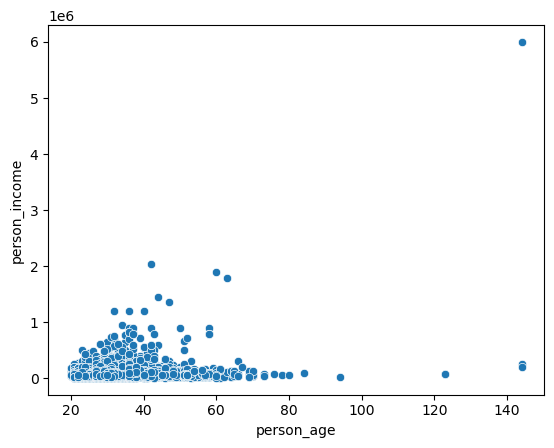

In [17]:
sns.scatterplot(x='person_age', y='person_income', data=df)

<Axes: xlabel='loan_intent', ylabel='count'>

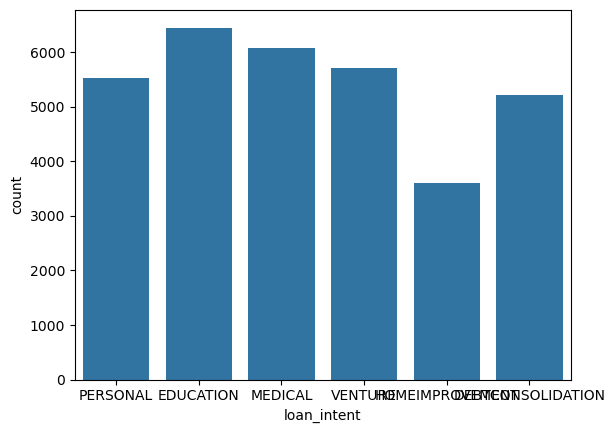

In [18]:
sns.countplot(x='loan_intent', data=df)

<Axes: xlabel='loan_grade', ylabel='count'>

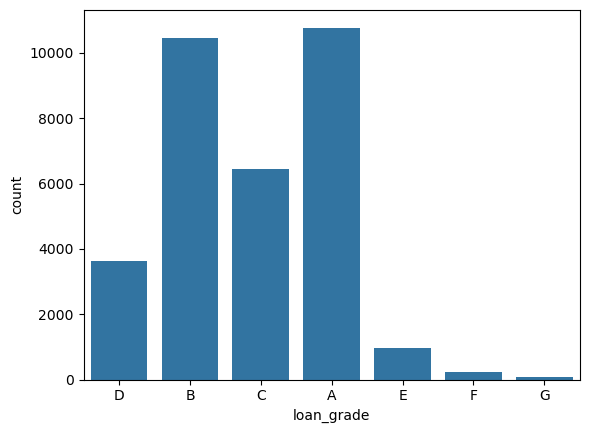

In [19]:
sns.countplot(x='loan_grade', data=df)

<Axes: xlabel='person_emp_length', ylabel='loan_amnt'>

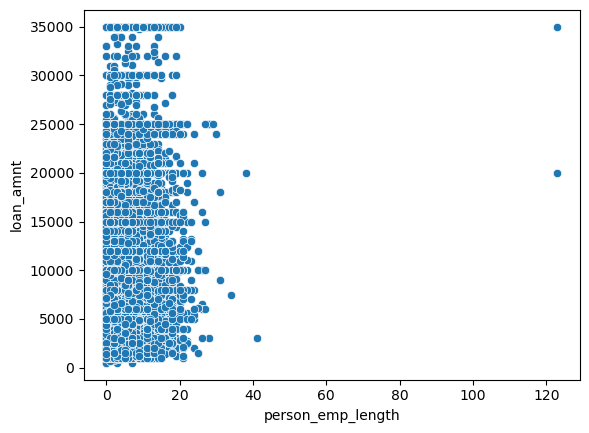

In [20]:
sns.scatterplot(x='person_emp_length',y='loan_amnt', data=df)

# Data Cleaning

In [21]:
df['person_emp_length'].fillna(df['person_emp_length'].mean(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].mean(), inplace=True)

C:\Users\44794\AppData\Local\Temp\ipykernel_23896\1813270452.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].mean(), inplace=True)
C:\Users\44794\AppData\Local\Temp\ipykernel_23896\1813270452.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

# Feature Engineering

In [22]:
grade_map = {'A': 'Low', 'B': 'Low', 'C': 'High', 'D': 'High'}
df['loan_grade_risk'] = df['loan_grade'].map(grade_map)
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_grade_risk
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,High
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,Low
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,High
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,High
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30,High
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19,Low
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28,Low
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26,Low


# Modelling

In [23]:
from sklearn.model_selection import train_test_split  # split data
from sklearn.linear_model import LinearRegression  # linear regression model
from sklearn.metrics import mean_squared_error, r2_score  # model evaluation
from sklearn.linear_model import LogisticRegression

In [28]:
# Define the dependent and independent variables
X = df[['person_age','person_income']]
y = df['loan_status']

In [29]:
# Changing y to a 1d-array
y = y.values.ravel()
y

array([1, 0, 1, ..., 1, 0, 0], dtype=int64)

In [24]:
# Split the training data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=1)

In [25]:
# Call the empty model

model = LogisticRegression()

In [26]:
# Balancing out the data set
model = LogisticRegression(class_weight="balanced", random_state=1)

In [27]:
# Train the model on our split data to find the coefficients

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=1)

In [28]:
# Predictions with a yes or no output at 0.5 threshold
predictions = model.predict(X_test)
print(predictions)

[1 0 1 ... 1 0 1]


In [29]:
# The numerical probability of default or no default
probabilities = model.predict_proba(X_test)
print(probabilities)

[[0.46077113 0.53922887]
 [0.56279127 0.43720873]
 [0.48338148 0.51661852]
 ...
 [0.38378091 0.61621909]
 [0.51500548 0.48499452]
 [0.42945748 0.57054252]]


In [30]:
# Creating a new DF to view actual and predicted

df_test = X_test.copy()
df_test

,person_age,person_income
29088,27,47900
24708,34,73000
22316,32,54000
15922,23,38000
4987,24,42996
...,...,...
2332,26,31200
1883,22,33996
19045,31,30000
9081,23,60000


In [31]:
# Taking only the right column so we can add it to a data frame
default_prob = probabilities[:,1]
default_prob

array([0.53922887, 0.43720873, 0.51661852, ..., 0.61621909, 0.48499452,
       0.57054252])

In [32]:
# adding in the other columns

df_test['predicted_default_prob'] = predictions
df_test['actual'] = y_test
df_test

,person_age,person_income,predicted_default_prob,actual
29088,27,47900,1,0
24708,34,73000,0,0
22316,32,54000,1,0
15922,23,38000,1,1
4987,24,42996,1,0
...,...,...,...,...
2332,26,31200,1,0
1883,22,33996,1,1
19045,31,30000,1,0
9081,23,60000,0,0


# Measuring model accuracy

## 1. Using accuracy e.g. correct predictions / total count

In [33]:
# So create a boolean mask for when the column predicted_default_prob is equal to our actual column.
# e.g. when there is a 0 in predicted and a 0 in actual that gives True. then calculate mean
accuracy = (df_test['predicted_default_prob'] == df_test['actual']).mean()
print(accuracy)

0.5838576031916526


## 2. Using confusion matrix 

In [34]:
from sklearn.metrics import confusion_matrix

In [35]:
cm = confusion_matrix(df_test['actual'], df_test['predicted_default_prob'])
print(cm)

[[2799 2306]
 [ 406 1006]]


In [ ]:
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].mean())
df = df.isnull().sum()
df

In [ ]:
# Replacing missing values in python with the mean

df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].mean())
df = df.isnull().sum()
df

In [ ]:
df2 = pd.isnull(df["person_emp_length"])
df3 = df[df2]
df3

In [ ]:
#Fill na

df4 = df.fillna(0)
df4

In [ ]:
df['loan_percent_income_sean'] = df['loan_amnt'] / df['person_income']
df

In [ ]:
df[df['loan_amnt'] <= 10000]

In [ ]:
df['loan_log'] = np.log(df['loan_amnt'])
df

In [ ]:
df.loc[3]

In [ ]:
df.loc[df['loan_amnt'] <= 10000, 'person_home_ownership']

In [ ]:
df.dtypes

In [ ]:
# Dropping missing values

df7 = df
df8 = df7.dropna()
df8.summary().show()

In [ ]:
# Dropping missing values

df7 = df
df8 = df7.dropna()
df8.describe()

In [ ]:
# Dropping missing values

df9 = df
df9 = df.fillna(df['person_emp_length'].mean())
df9.describe()